In [ ]:
!pip install -q datasets==2.15.0 torch torchvision scikit-learn pandas matplotlib

import os, random, numpy as np, torch
from pathlib import Path
seed=42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device", device)

device cuda


In [ ]:
!pip install -q datasets

In [ ]:
!pip uninstall -y datasets huggingface_hub
!pip install datasets==2.16.1
!pip install huggingface_hub==0.20.3

Found existing installation: datasets 2.15.0
Uninstalling datasets-2.15.0:
  Successfully uninstalled datasets-2.15.0
Found existing installation: huggingface-hub 0.20.3
Uninstalling huggingface-hub-0.20.3:
  Successfully uninstalled huggingface-hub-0.20.3
  Using cached datasets-2.16.1-py3-none-any.whl.metadata (20 kB)
  Using cached huggingface_hub-1.8.0-py3-none-any.whl.metadata (13 kB)
Using cached datasets-2.16.1-py3-none-any.whl (507 kB)
Using cached huggingface_hub-1.8.0-py3-none-any.whl (625 kB)
  Using cached huggingface_hub-0.20.3-py3-none-any.whl.metadata (12 kB)
Using cached huggingface_hub-0.20.3-py3-none-any.whl (330 kB)
  Attempting uninstall: huggingface_hub
    Found existing installation: huggingface_hub 1.8.0
    Uninstalling huggingface_hub-1.8.0:
      Successfully uninstalled huggingface_hub-1.8.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency confl

In [ ]:
from datasets import load_dataset


ds = load_dataset("Mireu-Lab/NSL-KDD")

train = ds['train'].to_pandas()
test = ds['test'].to_pandas()

print("train", train.shape, "test", test.shape)
train.head(2)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_token.py:88: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


train (151165, 42) test (34394, 42)


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,class
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,25,0.17,0.03,0.17,0.0,0.0,0.0,0.05,0.0,normal
1,0,udp,other,SF,146,0,0,0,0,0,...,1,0.00,0.60,0.88,0.0,0.0,0.0,0.00,0.0,normal


In [ ]:
print("train shape-", train.shape)
print("test shape-", test.shape)

train shape- (151165, 42)
test shape- (34394, 42)


In [ ]:
test.head()

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,class
0,13,tcp,telnet,SF,118,2425,0,0,0,0,...,10,0.38,0.12,0.04,0.0,0.00,0.00,0.12,0.3,anomaly
1,0,udp,private,SF,44,0,0,0,0,0,...,254,1.00,0.01,0.01,0.0,0.00,0.00,0.00,0.0,anomaly
2,0,tcp,telnet,S3,0,44,0,0,0,0,...,79,0.31,0.61,0.00,0.0,0.21,0.68,0.60,0.0,anomaly
3,0,udp,private,SF,53,55,0,0,0,0,...,255,1.00,0.00,0.87,0.0,0.00,0.00,0.00,0.0,normal
4,0,tcp,private,SH,0,0,0,0,0,0,...,1,0.06,1.00,1.00,0.0,1.00,1.00,0.00,0.0,anomaly


In [ ]:
train.head()

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,class
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,25,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal
1,0,udp,other,SF,146,0,0,0,0,0,...,1,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal
2,0,tcp,private,S0,0,0,0,0,0,0,...,26,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,anomaly
3,0,tcp,http,SF,232,8153,0,0,0,0,...,255,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal
4,0,tcp,http,SF,199,420,0,0,0,0,...,255,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal


In [ ]:
train['class'].value_counts()

,count
class,
normal,80792
anomaly,70373


In [ ]:
test['class'].value_counts()

,count
class,
anomaly,22531
normal,11863


In [ ]:
train['protocol_type'].value_counts()

,count
protocol_type,
tcp,123215
udp,18004
icmp,9946


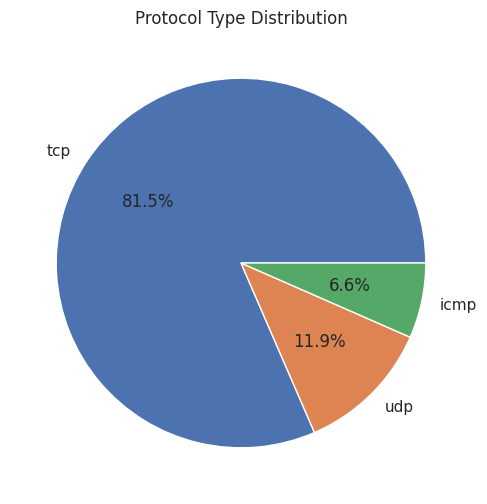

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()
data = train['protocol_type'].value_counts()

plt.figure(figsize=(6,6))
plt.pie(data.values, labels=data.index, autopct='%1.1f%%')
plt.title("Protocol Type Distribution")
plt.show()

In [ ]:
train.columns

Index(['duration', 'protocol_type', 'service', 'flag', 'src_bytes',
       'dst_bytes', 'land', 'wrong_fragment', 'urgent', 'hot',
       'num_failed_logins', 'logged_in', 'num_compromised', 'root_shell',
       'su_attempted', 'num_root', 'num_file_creations', 'num_shells',
       'num_access_files', 'num_outbound_cmds', 'is_host_login',
       'is_guest_login', 'count', 'srv_count', 'serror_rate',
       'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate',
       'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count',
       'dst_host_srv_count', 'dst_host_same_srv_rate',
       'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate',
       'dst_host_srv_diff_host_rate', 'dst_host_serror_rate',
       'dst_host_srv_serror_rate', 'dst_host_rerror_rate',
       'dst_host_srv_rerror_rate', 'class'],
      dtype='object')

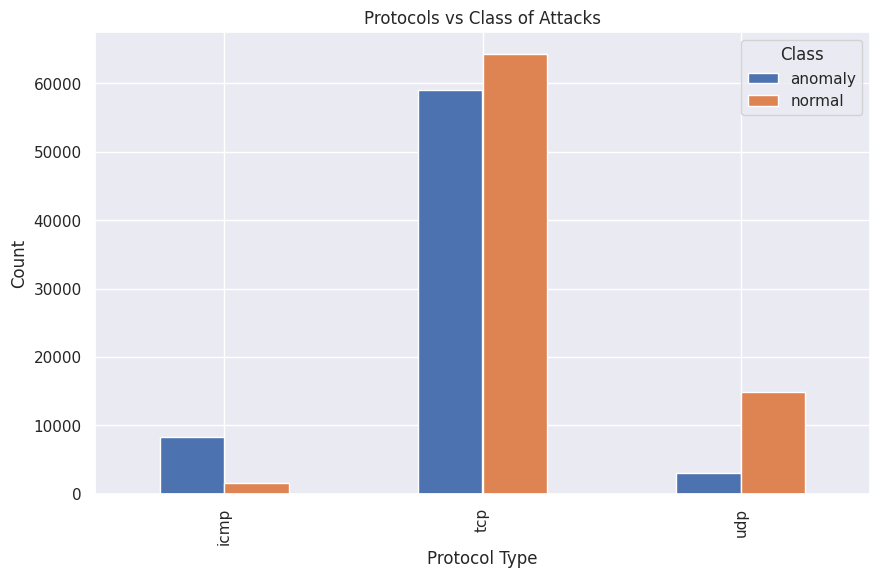

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

sns.set()

counts = train.groupby(['protocol_type', 'class']).size().unstack(fill_value=0)

counts.plot(kind='bar', figsize=(10,6))
plt.xlabel("Protocol Type")
plt.ylabel("Count")
plt.title("Protocols vs Class of Attacks")
plt.legend(title="Class")
plt.show()


In [ ]:
train['flag'].value_counts()

,count
flag,
SF,89918
S0,41860
REJ,13449
RSTR,2918
RSTO,1866
S1,453
SH,314
S2,148
RSTOS0,124


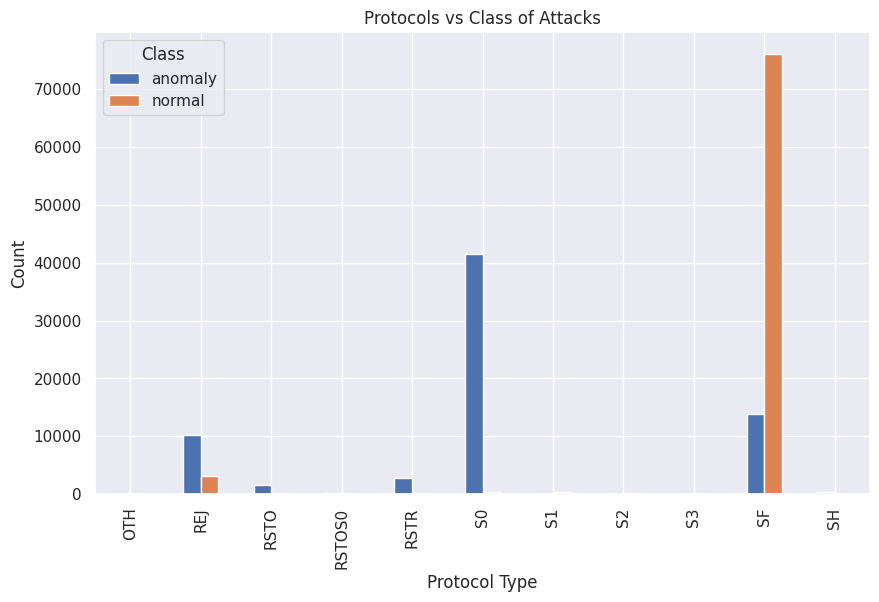

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

sns.set()

counts = train.groupby(['flag', 'class']).size().unstack(fill_value=0)

counts.plot(kind='bar', figsize=(10,6))
plt.xlabel("Protocol Type")
plt.ylabel("Count")
plt.title("Protocols vs Class of Attacks")
plt.legend(title="Class")
plt.show()


In [ ]:
train['class'] = train['class'].astype(str)
test['class'] = test['class'].astype(str)

seed = 42
train_normal = train[train['class']=='normal'].reset_index(drop=True)
val_normal = train_normal.sample(frac=0.1, random_state=seed)
train_normal = train_normal.drop(val_normal.index).reset_index(drop=True)

print("train_normal", train_normal.shape, "val_normal", val_normal.shape, "test", test.shape)

train_normal (72713, 42) val_normal (8079, 42) test (34394, 42)


In [ ]:
cols = [c for c in train.columns if c != 'class']
cat_cols = [c for c in cols if train[c].dtype == 'object']
num_cols = [c for c in cols if c not in cat_cols]

print("cols", cols)
print("cat_cols", cat_cols)
print("num_cols", num_cols)

cols ['duration', 'protocol_type', 'service', 'flag', 'src_bytes', 'dst_bytes', 'land', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins', 'logged_in', 'num_compromised', 'root_shell', 'su_attempted', 'num_root', 'num_file_creations', 'num_shells', 'num_access_files', 'num_outbound_cmds', 'is_host_login', 'is_guest_login', 'count', 'srv_count', 'serror_rate', 'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate', 'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count', 'dst_host_srv_count', 'dst_host_same_srv_rate', 'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate', 'dst_host_srv_diff_host_rate', 'dst_host_serror_rate', 'dst_host_srv_serror_rate', 'dst_host_rerror_rate', 'dst_host_srv_rerror_rate']
cat_cols ['protocol_type', 'service', 'flag']
num_cols ['duration', 'src_bytes', 'dst_bytes', 'land', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins', 'logged_in', 'num_compromised', 'root_shell', 'su_attempted', 'num_root', 'num_file_creations', 'num_shells'

In [ ]:
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

cols = [c for c in train.columns if c != 'class']
cat_cols = [c for c in cols if train[c].dtype == 'object']
num_cols = [c for c in cols if c not in cat_cols]

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols)
], remainder='drop')

preprocessor.fit(train_normal[cols])
X_train = preprocessor.transform(train_normal[cols])
X_val = preprocessor.transform(val_normal[cols])
X_test = preprocessor.transform(test[cols])

y_test = (test['class'] != 'normal').astype(int).values

print("X shapes:", X_train.shape, X_val.shape, X_test.shape)

X shapes: (72713, 77) (8079, 77) (34394, 77)


In [ ]:
X_train

array([[-0.12963834, -0.03088719, -0.06409798, ...,  0.        ,
         1.        ,  0.        ],
       [-0.12963834, -0.03174043, -0.06409798, ...,  0.        ,
         1.        ,  0.        ],
       [-0.12963834, -0.03152773,  0.05363196, ...,  0.        ,
         1.        ,  0.        ],
       ...,
       [-0.1234677 , -0.03184182, -0.06200417, ...,  0.        ,
         1.        ,  0.        ],
       [-0.12963834, -0.02658392, -0.05855299, ...,  0.        ,
         1.        ,  0.        ],
       [-0.12963834, -0.03172806, -0.06409798, ...,  0.        ,
         1.        ,  0.        ]])

In [ ]:
import tensorflow as tf
import numpy as np

input_dim = X_train.shape[1]

def build_encoder(input_dim):
    inp = tf.keras.Input(shape=(input_dim,))
    x = tf.keras.layers.Dense(256, activation='relu')(inp)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Dense(128, activation='relu')(x)
    x  = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Dense(64, activation='relu')(x)
    x = tf.keras.layers.BatchNormalization()(x)

    z = tf.keras.layers.Dense(128)(x)

    return tf.keras.Model(inp, z)


def build_decoder(output_dim):
    inp = tf.keras.Input(shape=(128,))
    x = tf.keras.layers.Dense(64, activation='relu')(inp)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Dense(128, activation='relu')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Dense(128, activation='relu')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Dense(256, activation='relu')(x)
    x = tf.keras.layers.BatchNormalization()(x)

    out = tf.keras.layers.Dense(output_dim)(x)

    return tf.keras.Model(inp, out)


def build_discriminator(input_dim):
    inp = tf.keras.Input(shape=(input_dim,))
    x = tf.keras.layers.Dense(256)(inp)
    x = tf.keras.layers.LeakyReLU(0.2)(x)

    x = tf.keras.layers.Dense(128)(x)
    x = tf.keras.layers.LeakyReLU(0.2)(x)

    out = tf.keras.layers.Dense(1, activation='sigmoid')(x)

    return tf.keras.Model(inp, out)


E = build_encoder(input_dim)
G = build_decoder(input_dim)
D = build_discriminator(input_dim)


In [ ]:
g_optimizer = tf.keras.optimizers.Adam(0.0002, beta_1=0.5)
d_optimizer = tf.keras.optimizers.Adam(0.0001, beta_1=0.5)

bce = tf.keras.losses.BinaryCrossentropy()
mse = tf.keras.losses.MeanSquaredError()


In [ ]:
batch_size = 128
epochs = 160

for epoch in range(epochs):

    idx = np.random.randint(0, X_train.shape[0], batch_size)
    real_data = X_train[idx]

    real_label = tf.ones((batch_size, 1))
    fake_label = tf.zeros((batch_size, 1))

    for _ in range(2):

        with tf.GradientTape() as tape:
            z = E(real_data, training=True)
            fake_data = G(z, training=True)

            real_out = D(real_data, training=True)
            fake_out = D(fake_data, training=True)

            d_loss = bce(real_label, real_out) + bce(fake_label, fake_out)

        grads = tape.gradient(d_loss, D.trainable_variables)
        grads = [(g, v) for g, v in zip(grads, D.trainable_variables) if g is not None]
        d_optimizer.apply_gradients(grads)

    with tf.GradientTape() as tape:
        z = E(real_data, training=True)
        fake_data = G(z, training=True)
        fake_out = D(fake_data, training=False)

        recon_loss = mse(real_data, fake_data)
        adv_loss = bce(real_label, fake_out)

        g_loss = 0.95 * recon_loss + 0.05 * adv_loss

    train_vars = E.trainable_variables + G.trainable_variables
    grads = tape.gradient(g_loss, train_vars)
    grads = [(g, v) for g, v in zip(grads, train_vars) if g is not None]
    g_optimizer.apply_gradients(grads)

    if epoch % 20 == 0:
        print(f"Epoch {epoch} | D Loss: {d_loss.numpy():.4f} | G Loss: {g_loss.numpy():.4f}")


Epoch 0 | D Loss: 1.3579 | G Loss: 1.8074
Epoch 20 | D Loss: 1.0188 | G Loss: 0.9344
Epoch 40 | D Loss: 0.8966 | G Loss: 0.6016
Epoch 60 | D Loss: 1.0039 | G Loss: 1.9381
Epoch 80 | D Loss: 0.8020 | G Loss: 0.3789
Epoch 100 | D Loss: 0.7906 | G Loss: 0.4642
Epoch 120 | D Loss: 0.7696 | G Loss: 0.2939
Epoch 140 | D Loss: 0.8231 | G Loss: 0.2003


In [ ]:
z_train = E(X_train, training=False)
recon_train = G(z_train, training=False)

recon_loss_train = tf.reduce_mean(tf.square(X_train - recon_train), axis=1)
disc_score_train = tf.squeeze(D(recon_train, training=False))

anomaly_score_train = (
    0.7 * recon_loss_train +
    0.3 * (1 - disc_score_train)
).numpy()

threshold = np.percentile(anomaly_score_train, 75)



print("Threshold:", threshold)


Threshold: 0.28927663


In [ ]:
z_test = E(X_test, training=False)
recon_test = G(z_test, training=False)

recon_loss_test = tf.reduce_mean(tf.square(X_test - recon_test), axis=1)
disc_score_test = tf.squeeze(D(recon_test, training=False))

anomaly_score_test = (
    0.7 * recon_loss_test +
    0.3 * (1 - disc_score_test)
).numpy()

y_pred = (anomaly_score_test > threshold).astype(int)


from sklearn.metrics import classification_report, roc_auc_score

print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, anomaly_score_test))

              precision    recall  f1-score   support

           0       0.80      0.75      0.77     11863
           1       0.87      0.90      0.89     22531

    accuracy                           0.85     34394
   macro avg       0.84      0.82      0.83     34394
weighted avg       0.85      0.85      0.85     34394

ROC-AUC: 0.9120330929742688


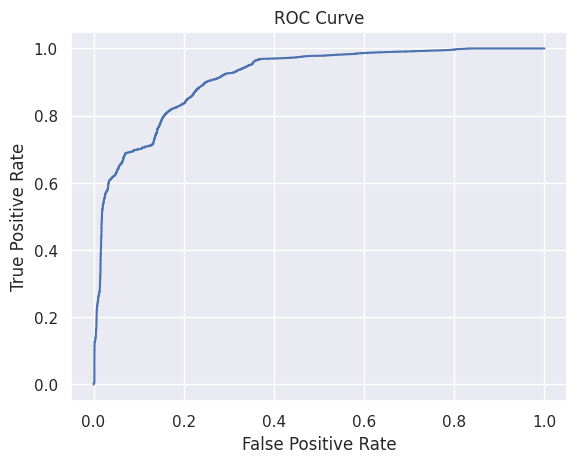

In [ ]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr, tpr, _ = roc_curve(y_test, anomaly_score_test)

plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()


In [ ]:
def predict_normal_attack(X_input):

    z = E(X_input, training=False)
    recon = G(z, training=False)

    recon_loss = tf.reduce_mean(tf.square(X_input - recon), axis=1)
    disc_score = tf.squeeze(D(recon, training=False))

    anomaly_score = (
        0.7 * recon_loss +
        0.3 * (1 - disc_score)
    ).numpy()

    prediction = (anomaly_score > threshold).astype(int)

    return prediction


In [ ]:
predictions = predict_normal_attack(X_test[1: 100])
print(predictions)


[1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 0 1 0 1 1 1 0 0 1 0 1 1
 1 1 0 0 1 1 1 1 1 1 1 1 1 0 1 0 1 1 1 1 1 0 1 1 0 0 1 1 1 1 1 1 1 1 1 0 1
 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 0 1 0 0 0 1 1]


In [ ]:
sample = X_test[23:30]
prediction = predict_normal_attack(sample)

for i in range(len(sample)):
    if prediction[i] == 0:
        print("Normal Traffic")
    else:
        print("Attack Detected")

Normal Traffic
Attack Detected
Attack Detected
Normal Traffic
Attack Detected
Normal Traffic
Attack Detected
